In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# Dataset
transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True)

# VAE Model
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, 2)      # latent dim = 2 (for visualization)
        self.fc_logvar = nn.Linear(400, 2)
        self.fc2 = nn.Linear(2, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Loss
def loss_fn(recon, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Train
for epoch in range(5):
    for data, _ in train_loader:
        data = data.view(-1, 784).to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = loss_fn(recon, data, mu, logvar)
        loss.backward()
        optimizer.step()

print("Training Done")

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.79MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.45MB/s]


Training Done


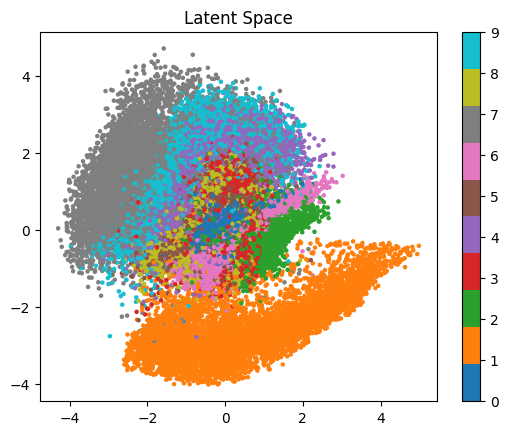

In [ ]:
import numpy as np

model.eval()
zs = []
labels = []

with torch.no_grad():
    for data, label in train_loader:
        data = data.view(-1, 784).to(device)
        mu, _ = model.encode(data)
        zs.append(mu.cpu())
        labels.append(label)

zs = torch.cat(zs).numpy()
labels = torch.cat(labels).numpy()

plt.scatter(zs[:, 0], zs[:, 1], c=labels, cmap='tab10', s=5)
plt.colorbar()
plt.title("Latent Space")
plt.show()

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

G = Generator().to(device)
D = Discriminator().to(device)

loss_fn = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

In [ ]:
for epoch in range(5):
    for real, _ in train_loader:
        real = real.view(-1, 784).to(device)

        # Train Discriminator
        z = torch.randn(real.size(0), 100).to(device)
        fake = G(z)

        loss_D = loss_fn(D(real), torch.ones_like(D(real))) + \
                 loss_fn(D(fake.detach()), torch.zeros_like(D(fake)))

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        loss_G = loss_fn(D(fake), torch.ones_like(D(fake)))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

print("GAN Training Done")

GAN Training Done


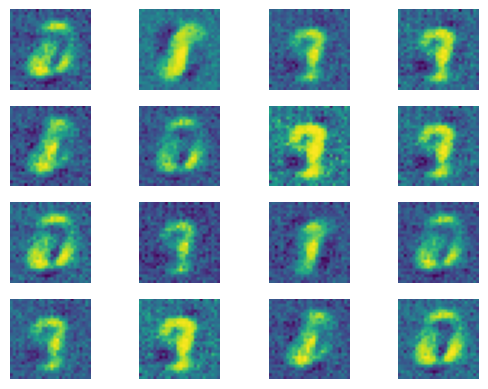

In [ ]:
z = torch.randn(16, 100).to(device)
fake_images = G(z).view(-1, 28, 28).detach().cpu()

fig, axes = plt.subplots(4, 4)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake_images[i])
    ax.axis('off')

plt.show()

In [ ]:
from torch_geometric.datasets import Planetoid
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

dataset = Planetoid(root='/tmp/Cora', name='Cora')

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = GCN()
data = dataset[0]

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

print("GCN Training Done")